# Bike Rental Demand — LightGBM

Gradient-boosted tree modelling for daily bicycle-rental demand. The notebook preserves the original tuning, validation and residual checks so the boosted model can be compared with the linear and Random Forest approaches.

> **Portfolio note:** This notebook is a curated version of completed MSc coursework. The analytical code and saved outputs come from the original work; presentation, headings, file paths and explanatory text have been cleaned for portfolio use. The dataset itself is not redistributed here.


**IMPORTS**


In [1]:
# Importing the libraries
import numpy as np # for array operations
import pandas as pd # for working with DataFrames
import requests, io # for HTTP requests and I/O commands
import matplotlib.pyplot as plt # for data visualization
import holoviews as hv
import os
from IPython.display import display, HTML
%matplotlib inline

# scikit-learn modules
from sklearn.pipeline import Pipeline
from lightgbm import LGBMRegressor
from sklearn.ensemble import RandomForestRegressor  # or RandomForestRegressor for regression
from sklearn.tree import DecisionTreeRegressor  # Use DecisionTreeRegressor for regression tasks
from sklearn.preprocessing import StandardScaler, PolynomialFeatures, MinMaxScaler, RobustScaler
from sklearn.model_selection import cross_val_score, BaseCrossValidator, GridSearchCV, train_test_split
from sklearn import metrics
from sklearn.metrics import r2_score, root_mean_squared_error, mean_squared_error
from sklearn.inspection import PartialDependenceDisplay
from sklearn.impute import SimpleImputer
from sklearn.base import clone


**CONSTANTS**


In [3]:
FILE_PATH = 'data/bike_output.csv'


**OPTIONS**


**METHODS**


In [10]:
import numpy as np
import pandas as pd
from sklearn.model_selection import BaseCrossValidator
from sklearn.utils.validation import _num_samples
import warnings

class ExpandingWindowSplitRemainderTest(BaseCrossValidator):
    """
    Expanding Window Cross-Validator: Test on All Remaining Data.

    Splits the data into training and test sets based on sorted month periods.
    The training set size expands in each split. The test set consists of *all*
    data chronologically after the training set (plus any specified gap).

    Includes verbose printing during split generation.

    Parameters
    ----------
    month_series : pd.Series
        A pandas Series where the index corresponds to the sample index in X/y,
        and the values are comparable month identifiers (e.g., pd.Period, 'YYYY-MM').
        Must contain sorted unique months reflecting chronology.

    initial_train_months : int
        The number of months to include in the first training split.

    expansion_step_months : int, default=1
        The number of months by which the training set expands for the *next* fold.
        Typically set to the desired frequency of model retraining/evaluation (e.g., 1 for monthly).

    gap_months : int, default=0
        The number of months to skip between the end of the training set
        and the beginning of the test set.

    max_splits : int or None, default=None
        The maximum number of splits to generate. If None, all possible splits
        according to the parameters will be generated.

    verbose : bool, default=True
        If True, prints details about each fold during the split process.

    Attributes
    ----------
    unique_months_ : np.ndarray
        Sorted unique month values found in `month_series`.

    n_splits_ : int
        The number of splits generated.
    """
    def __init__(self, month_series, initial_train_months, expansion_step_months=1,
                 gap_months=0, max_splits=None, verbose=True): # Renamed test_months
        if not isinstance(month_series, pd.Series):
            raise ValueError("month_series must be a pandas Series.")
        if initial_train_months < 1:
            raise ValueError("initial_train_months must be at least 1.")
        if expansion_step_months < 1: # Check expansion step
            raise ValueError("expansion_step_months must be at least 1.")
        if gap_months < 0:
            raise ValueError("gap_months cannot be negative.")

        self.month_series = month_series
        self.initial_train_months = initial_train_months
        self.expansion_step_months = expansion_step_months # Store expansion step
        self.gap_months = gap_months
        self.max_splits = max_splits
        self.verbose = verbose

        # Store unique sorted months
        self.unique_months_ = np.sort(month_series.unique())
        self.n_total_months_ = len(self.unique_months_)

        # Check if ANY test data is possible for the first split
        first_test_start_idx = self.initial_train_months + self.gap_months
        if first_test_start_idx >= self.n_total_months_:
             raise ValueError(
                 f"Not enough months ({self.n_total_months_}) for any test data "
                 f"with initial_train_months={initial_train_months} and "
                 f"gap_months={gap_months}. Need at least {first_test_start_idx + 1} months."
             )

        # Pre-calculate the number of splits
        self.n_splits_ = self._calculate_n_splits()
        if self.verbose:
            print(f"ExpandingWindowSplitRemainderTest initialized: Found {self.n_total_months_} unique months.")
            print(f"Calculated {self.n_splits_} possible splits based on parameters.")

    def _calculate_n_splits(self):
        """Calculates the total number of splits possible."""
        max_possible_splits = 0
        current_train_end_idx = self.initial_train_months
        while True:
            # Test data starts after train + gap
            test_start_idx = current_train_end_idx + self.gap_months
            # A split is possible as long as there's at least one month for testing
            if test_start_idx < self.n_total_months_:
                max_possible_splits += 1
                # Training data expands by the step size for the next potential split
                current_train_end_idx += self.expansion_step_months
            else:
                break # Cannot form another split (no test data possible)

        if self.max_splits is not None:
            return min(max_possible_splits, self.max_splits)
        else:
            return max_possible_splits

    def get_n_splits(self, X=None, y=None, groups=None):
        """Returns the number of splitting iterations in the cross-validator."""
        return self.n_splits_

    def split(self, X, y=None, groups=None):
        """Generate indices to split data into training and test set."""
        n_samples = _num_samples(X)
        # Index handling (same as previous version)
        if isinstance(X, pd.DataFrame) and X.index.equals(self.month_series.index):
             indices = self.month_series.index.to_numpy()
        elif isinstance(X, pd.Series) and X.index.equals(self.month_series.index):
             indices = self.month_series.index.to_numpy()
        else:
             if n_samples != len(self.month_series):
                 warnings.warn(f"Number of samples in X ({n_samples}) differs from "
                               f"length of month_series ({len(self.month_series)}). "
                               f"Ensure month_series corresponds row-wise to X.")
             indices = np.arange(n_samples)

        current_train_end_idx = self.initial_train_months
        splits_generated = 0

        while splits_generated < self.n_splits_:
            fold_num = splits_generated + 1
            test_start_idx = current_train_end_idx + self.gap_months
            # Test end is ALWAYS the end of the data
            test_end_idx = self.n_total_months_

            # Boundary check: Ensure test_start_idx is valid
            if test_start_idx >= self.n_total_months_:
                if self.verbose:
                    print(f"Stopping split generation: Cannot form test set starting at index {test_start_idx} "
                          f"with total months {self.n_total_months_}")
                break

            train_months = self.unique_months_[0:current_train_end_idx]
            test_months_fold = self.unique_months_[test_start_idx:test_end_idx]

            # Get boolean masks
            train_mask = self.month_series.isin(train_months)
            test_mask = self.month_series.isin(test_months_fold)

            # Select indices
            train_idx = indices[train_mask.to_numpy(dtype=bool)]
            test_idx = indices[test_mask.to_numpy(dtype=bool)]

            if self.verbose:
                print(f"\n--- Fold {fold_num}/{self.n_splits_} ---")
                print(f"  Train months ({len(train_months)}): {train_months[0]} to {train_months[-1]}")
                if len(test_months_fold) > 0:
                    print(f"  Test months  ({len(test_months_fold)}): {test_months_fold[0]} to {test_months_fold[-1]} (Remainder)")
                else:
                    print(f"  Test months  (0): None (Should not happen with checks)") # Should not happen if checks are right
                print(f"  Train indices: {len(train_idx)}")
                print(f"  Test indices : {len(test_idx)}")

            if len(test_idx) == 0 and len(test_months_fold) > 0 :
                 warnings.warn(f"Fold {fold_num}: Test set is empty despite having test months "
                               f"{test_months_fold}. Check data alignment.", UserWarning)
            if len(train_idx) == 0:
                 warnings.warn(f"Fold {fold_num}: Train set is empty for months "
                               f"{train_months}. Check initial_train_months.", UserWarning)

            yield train_idx, test_idx

            # Expand the training window for the next iteration by the step size
            current_train_end_idx += self.expansion_step_months
            splits_generated += 1


**LOAD DATA**


In [13]:
df_bike_model = pd.read_csv(FILE_PATH)


In [15]:
df_bike_model['dteday'] = pd.to_datetime(df_bike_model['dteday'])
df_bike_model.sort_values('dteday', inplace=True)
df_bike_model.drop('Unnamed: 0', axis=1, inplace=True)


In [17]:
df_bike_model.head()


,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,atemp,hum,windspeed,cnt
0,2011-01-01,1,0,1,0,6.0,0,2,0.363625,0.805833,0.160446,985
1,2011-01-02,1,0,1,0,0.0,0,2,0.353739,0.696087,0.248539,801
2,2011-01-03,1,0,1,0,1.0,1,1,0.189405,0.437273,0.248309,1349
3,2011-01-04,1,0,1,0,2.0,1,1,0.212122,0.590435,0.160296,1562
4,2011-01-05,1,0,1,0,3.0,1,1,0.229270,0.436957,0.186900,1600


In [19]:
df_bike_model.tail()


,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,atemp,hum,windspeed,cnt
726,2012-12-27,1,1,12,0,4.0,1,2,0.226642,0.652917,0.350133,2114
727,2012-12-28,1,1,12,0,5.0,1,2,0.255046,0.590000,0.155471,3095
728,2012-12-29,1,1,12,0,6.0,0,2,0.242400,0.752917,0.124383,1341
729,2012-12-30,1,1,12,0,0.0,0,1,0.231700,0.483333,0.350754,1796
730,2012-12-31,1,1,12,0,1.0,1,2,0.223487,0.577500,0.154846,2729


**PREPARING DATA FOR MODELING**


In [130]:
# Create the 'year_month' column as before
df_bike_model['year_month'] = df_bike_model['dteday'].dt.to_period('M')
month_series = df_bike_model['year_month'] # Ensure index matches X

df_bike_model['time_idx'] = df_bike_model.index

# 4. Lag Features (Using shift(1) as primary, keep shift(2) based on your comment, correct shift(7))
# shift(2): Day before yesterday's count (as per your comment)
df_bike_model['cnt_lag2'] = df_bike_model['cnt'].shift(2)
df_bike_model['cnt_lag7'] = df_bike_model['cnt'].shift(7)
df_bike_model['cnt_lag14'] = df_bike_model['cnt'].shift(14)

# 5. Rolling Window Features (Based on shift(1) to use most recent complete day)
# Use closed='left' to ensure the window includes data up to, but not including, the current day
df_bike_model['cnt_roll3_lag2'] = df_bike_model['cnt'].shift(2).rolling(window=3, closed='left').median()
df_bike_model['cnt_roll7_lag2'] = df_bike_model['cnt'].shift(2).rolling(window=7, closed='left').median()
df_bike_model['cnt_roll14_lag2'] = df_bike_model['cnt'].shift(2).rolling(window=14, closed='left').median()

df_bike_model['cnt_diff'] = df_bike_model['cnt'].shift(2).diff()
df_bike_model['cnt_diff_roll4'] = df_bike_model['cnt'].shift(2).diff().rolling(window=3, closed='left').mean()

df_bike_model['atemp_roll3_lag2'] = df_bike_model['atemp'].shift(2).rolling(window=3, closed='left').mean()
df_bike_model['atemp_roll7_lag2'] = df_bike_model['atemp'].shift(2).rolling(window=7, closed='left').mean()

df_bike_model['hum_lag2'] = df_bike_model['hum'].shift(2)
df_bike_model['hum_roll3_lag2'] = df_bike_model['hum'].shift(2).rolling(window=3, closed='left').mean()
df_bike_model['hum_roll7_lag2'] = df_bike_model['hum'].shift(2).rolling(window=7, closed='left').mean()


In [132]:
# unique_months is a sorted array of the unique 'year_month' values in the dataset.
unique_months = np.array(sorted(df_bike_model['year_month'].unique()))
print("Unique months:", unique_months)
print("Total months:", len(unique_months))


Unique months: [Period('2011-01', 'M') Period('2011-02', 'M') Period('2011-03', 'M')
 Period('2011-04', 'M') Period('2011-05', 'M') Period('2011-06', 'M')
 Period('2011-07', 'M') Period('2011-08', 'M') Period('2011-09', 'M')
 Period('2011-10', 'M') Period('2011-11', 'M') Period('2011-12', 'M')
 Period('2012-01', 'M') Period('2012-02', 'M') Period('2012-03', 'M')
 Period('2012-04', 'M') Period('2012-05', 'M') Period('2012-06', 'M')
 Period('2012-07', 'M') Period('2012-08', 'M') Period('2012-09', 'M')
 Period('2012-10', 'M') Period('2012-11', 'M') Period('2012-12', 'M')]
Total months: 24


In [134]:
df_bike_model.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 29 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   dteday                731 non-null    datetime64[ns]
 1   season                731 non-null    int64         
 2   yr                    731 non-null    int64         
 3   mnth                  731 non-null    int64         
 4   holiday               731 non-null    int64         
 5   weekday               729 non-null    float64       
 6   workingday            731 non-null    int64         
 7   weathersit            731 non-null    int64         
 8   atemp                 731 non-null    float64       
 9   hum                   731 non-null    float64       
 10  windspeed             731 non-null    float64       
 11  cnt                   731 non-null    int64         
 12  year_month            731 non-null    period[M]     
 13  time_idx            

In [136]:
df_bike_model.head()


,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,atemp,hum,windspeed,cnt,year_month,time_idx,cnt_lag2,cnt_lag7,cnt_lag14,cnt_roll3_lag2,cnt_roll7_lag2,cnt_roll14_lag2,cnt_diff,cnt_diff_roll4,atemp_roll3_lag2,atemp_roll7_lag2,hum_roll3_lag2,hum_roll7_lag2,windspeed_roll3_lag2,windspeed_roll7_lag2,hum_lag2
0,2011-01-01,1,0,1,0,6.0,0,2,0.363625,0.805833,0.160446,985,2011-01,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2011-01-02,1,0,1,0,0.0,0,2,0.353739,0.696087,0.248539,801,2011-01,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2011-01-03,1,0,1,0,1.0,1,1,0.189405,0.437273,0.248309,1349,2011-01,2,985.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.805833
3,2011-01-04,1,0,1,0,2.0,1,1,0.212122,0.590435,0.160296,1562,2011-01,3,801.0,NaN,NaN,NaN,NaN,NaN,-184.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.696087
4,2011-01-05,1,0,1,0,3.0,1,1,0.229270,0.436957,0.186900,1600,2011-01,4,1349.0,NaN,NaN,NaN,NaN,NaN,548.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.437273


In [138]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.pipeline import Pipeline
# from sklearn.impute import SimpleImputer # Uncomment if needed
# from sklearn.preprocessing import StandardScaler # Uncomment if needed
from sklearn.model_selection import GridSearchCV

# Assume X and y are prepared (features and target)
# Ensure X and y use the same index as month_series
feature_cols = [
    'season', 'yr', 'mnth', 'holiday', 'weekday', 'workingday', 'weathersit', # RAW FEATURES
    'atemp', 'hum', 'windspeed', # RAW FEATURES
    'cnt_diff', 'cnt_lag2', 'cnt_lag7', # PREVIOUS TARGETS
    'atemp_roll3_lag2', 'atemp_roll7_lag2', # PREVIOUS TEMP
    'hum_roll3_lag2', 'hum_roll7_lag2', # PREVIOUS HUM
    'hum_lag2',
]
target_col = 'cnt'

X = df_bike_model[feature_cols]
y = df_bike_model[target_col]


In [140]:
X.head()


,season,yr,mnth,holiday,weekday,workingday,weathersit,atemp,hum,windspeed,cnt_diff,cnt_lag2,cnt_lag7,atemp_roll3_lag2,atemp_roll7_lag2,hum_roll3_lag2,hum_roll7_lag2,hum_lag2
0,1,0,1,0,6.0,0,2,0.363625,0.805833,0.160446,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1,0,1,0,0.0,0,2,0.353739,0.696087,0.248539,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1,0,1,0,1.0,1,1,0.189405,0.437273,0.248309,NaN,985.0,NaN,NaN,NaN,NaN,NaN,0.805833
3,1,0,1,0,2.0,1,1,0.212122,0.590435,0.160296,-184.0,801.0,NaN,NaN,NaN,NaN,NaN,0.696087
4,1,0,1,0,3.0,1,1,0.229270,0.436957,0.186900,548.0,1349.0,NaN,NaN,NaN,NaN,NaN,0.437273


In [142]:
X.tail()


,season,yr,mnth,holiday,weekday,workingday,weathersit,atemp,hum,windspeed,cnt_diff,cnt_lag2,cnt_lag7,atemp_roll3_lag2,atemp_roll7_lag2,hum_roll3_lag2,hum_roll7_lag2,hum_lag2
726,1,1,12,0,4.0,1,2,0.226642,0.652917,0.350133,93.0,1013.0,4128.0,0.251495,0.306191,0.582657,0.609175,0.734783
727,1,1,12,0,5.0,1,2,0.255046,0.590000,0.155471,-572.0,441.0,3623.0,0.270945,0.289728,0.680501,0.618965,0.823333
728,1,1,12,0,6.0,0,2,0.242400,0.752917,0.124383,1673.0,2114.0,1749.0,0.257899,0.272324,0.783140,0.647239,0.652917
729,1,1,12,0,0.0,0,1,0.231700,0.483333,0.350754,981.0,3095.0,1787.0,0.247147,0.256813,0.737011,0.645096,0.590000
730,1,1,12,0,1.0,1,2,0.223487,0.577500,0.154846,-1754.0,1341.0,920.0,0.234007,0.250139,0.688750,0.649858,0.752917


In [144]:
y.head()


0     985
1     801
2    1349
3    1562
4    1600
Name: cnt, dtype: int64

In [146]:
import pandas as pd
import numpy as np
from sklearn.model_selection import GridSearchCV
# from sklearn.ensemble import RandomForestRegressor # No longer needed
from lightgbm import LGBMRegressor # Import LightGBM
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
# from sklearn.preprocessing import StandardScaler # Still keep commented

# --- Assume previous code for data loading, feature engineering ---
# Ensure X, y, month_series, and the CV class (e.g., ExpandingWindowSplit or ExpandingWindowSplitRemainderTest) are defined
# Example using ExpandingWindowSplitRemainderTest for consistency with previous steps
# from your_module import ExpandingWindowSplitRemainderTest # Or paste class definition

# --- Pipeline Setup ---

# Create a pipeline for LightGBM
pipeline_lgbm = Pipeline([ # Renamed variable for clarity
    ('imputer', SimpleImputer(strategy='median')), # Keep imputer
    ('lgbm', LGBMRegressor(random_state=42)) # Replace RF with LGBM, update step name
])

# --- Parameter Grid Setup ---

# Define a parameter grid for LightGBM
# Note: Hyperparameter names and typical ranges differ from RandomForest
param_grid_lgbm = {
    # Keep learning rate reasonable
    'lgbm__learning_rate': [0.05],
    # Reduce n_estimators initially to speed up grid search during debugging
    'lgbm__n_estimators': [200],
    # Ensure num_leaves is not too small
    'lgbm__num_leaves': [30, 60],
     # Key change: Drastically reduce min_child_samples
    'lgbm__min_child_samples': [1, 2], # <-- TRY MUCH SMALLER VALUES
    # Keep max_depth reasonable or unlimited
    'lgbm__max_depth': [5],
    # Keep colsample_bytree reasonable
    'lgbm__colsample_bytree': [1]
}

# --- Cross-Validator Setup ---

# Instantiate the Custom Cross-Validator (Using one of the previously defined classes)
# Using ExpandingWindowSplitRemainderTest as an example here
# Make sure 'month_series' is correctly defined from your data prep steps
cv = ExpandingWindowSplitRemainderTest( # Or ExpandingWindowSplit if preferred
    month_series=month_series,
    initial_train_months=14,
    expansion_step_months=1,  # Parameter for RemainderTest version
    # test_months=1,          # Parameter for Fixed Window version
    gap_months=0,
    max_splits=5,
    verbose=True # Keep verbose output for CV splits
)

# --- Run GridSearchCV ---

# Set up GridSearchCV with the LightGBM pipeline and grid
gs = GridSearchCV(
    estimator=pipeline_lgbm,      # Use the LGBM pipeline
    param_grid=param_grid_lgbm,   # Use the LGBM parameter grid
    cv=cv,                        # Use the custom time series CV
    scoring={'r2': 'r2', 'rmse': 'neg_root_mean_squared_error'},
    refit='r2',                   # Or 'rmse'
    n_jobs=-1,                    # Use all available CPU cores
    verbose=1                     # Show GridSearchCV progress
)

print("\nStarting GridSearchCV Fit with LightGBM...")
# Fit (Ensure X, y indices/rows align with month_series)
gs.fit(X, y) # Use the same X and y from feature engineering

print("\nGridSearchCV Fit Complete.")


ExpandingWindowSplitRemainderTest initialized: Found 24 unique months.
Calculated 5 possible splits based on parameters.

Starting GridSearchCV Fit with LightGBM...
Fitting 5 folds for each of 4 candidates, totalling 20 fits

--- Fold 1/5 ---
  Train months (14): 2011-01 to 2012-02
  Test months  (10): 2012-03 to 2012-12 (Remainder)
  Train indices: 425
  Test indices : 306

--- Fold 2/5 ---
  Train months (15): 2011-01 to 2012-03
  Test months  (9): 2012-04 to 2012-12 (Remainder)
  Train indices: 456
  Test indices : 275

--- Fold 3/5 ---
  Train months (16): 2011-01 to 2012-04
  Test months  (8): 2012-05 to 2012-12 (Remainder)
  Train indices: 486
  Test indices : 245

--- Fold 4/5 ---
  Train months (17): 2011-01 to 2012-05
  Test months  (7): 2012-06 to 2012-12 (Remainder)
  Train indices: 517
  Test indices : 214

--- Fold 5/5 ---
  Train months (18): 2011-01 to 2012-06
  Test months  (6): 2012-07 to 2012-12 (Remainder)
  Train indices: 547
  Test indices : 184
[LightGBM] [Warning

In [147]:
# --- Display Results ---
print("\nBest Parameters Found (LightGBM):")
print(gs.best_params_)
print(f"\nBest CV R² Score ({gs.refit}): {gs.best_score_:.4f}")



Best Parameters Found (LightGBM):
{'lgbm__colsample_bytree': 1, 'lgbm__learning_rate': 0.05, 'lgbm__max_depth': 5, 'lgbm__min_child_samples': 2, 'lgbm__n_estimators': 200, 'lgbm__num_leaves': 60}

Best CV R² Score (r2): 0.2909


In [148]:
print("\nFull CV Results (LightGBM):")
cv_results_df = pd.DataFrame(gs.cv_results_)
# Select columns relevant to scoring and params for brevity
cv_results_df.sort_values('rank_test_r2').head()



Full CV Results (LightGBM):


,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_lgbm__colsample_bytree,param_lgbm__learning_rate,param_lgbm__max_depth,param_lgbm__min_child_samples,param_lgbm__n_estimators,param_lgbm__num_leaves,params,split0_test_r2,split1_test_r2,split2_test_r2,split3_test_r2,split4_test_r2,mean_test_r2,std_test_r2,rank_test_r2,split0_test_rmse,split1_test_rmse,split2_test_rmse,split3_test_rmse,split4_test_rmse,mean_test_rmse,std_test_rmse,rank_test_rmse
3,2.953426,1.398042,0.004498,0.000562,1,0.05,5,2,200,60,"{'lgbm__colsample_bytree': 1, 'lgbm__learning_...",-0.734586,0.480329,0.533200,0.570916,0.604620,0.290896,0.514402,1,-2063.951983,-1138.851707,-1098.399896,-1094.551547,-1094.810174,-1298.113061,383.282699,1
2,5.645622,0.090207,0.004976,0.000513,1,0.05,5,2,200,30,"{'lgbm__colsample_bytree': 1, 'lgbm__learning_...",-0.728335,0.461726,0.528303,0.575569,0.590196,0.285492,0.508891,2,-2060.229325,-1159.056291,-1104.146708,-1088.600250,-1114.601829,-1305.326881,378.177928,2
0,6.928385,0.128412,0.004686,0.000077,1,0.05,5,1,200,30,"{'lgbm__colsample_bytree': 1, 'lgbm__learning_...",-0.752260,0.440174,0.528345,0.575008,0.605691,0.279392,0.518844,3,-2074.440301,-1182.032659,-1104.097059,-1089.319414,-1093.326827,-1308.643252,384.390067,3
1,6.575758,0.384695,0.005099,0.000309,1,0.05,5,1,200,60,"{'lgbm__colsample_bytree': 1, 'lgbm__learning_...",-0.780957,0.446101,0.499894,0.574138,0.612775,0.270390,0.528842,4,-2091.357918,-1175.759103,-1136.910478,-1090.433871,-1083.461478,-1315.584570,389.326045,4


**NOW TRAIN TEST USING THE BEST PARAMS WE'VE FOUND**


In [183]:
df_train = df_bike_model.loc[df_bike_model.dteday < '2012-03-01']
df_test = df_bike_model.loc[df_bike_model.dteday >= '2012-03-01']

X_train = df_train[feature_cols]
X_test = df_test[feature_cols]
y_train = df_train[target_col]
y_test = df_test[target_col]


In [185]:
final_model = Pipeline([ # Renamed variable for clarity
    ('imputer', SimpleImputer(strategy='median')), # Keep imputer
    # ('scaler', StandardScaler()), # Keep commented
    ('lgbm', LGBMRegressor(random_state=42)) # Replace RF with LGBM, update step name
])
final_model.set_params(**gs.best_params_)


Pipeline(steps=[('imputer', SimpleImputer(strategy='median')),
                ('lgbm',
                 LGBMRegressor(colsample_bytree=1, learning_rate=0.05,
                               max_depth=5, min_child_samples=2,
                               n_estimators=200, num_leaves=60,
                               random_state=42))])

In [187]:
final_model.fit(X_train, y_train)


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000342 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1597
[LightGBM] [Info] Number of data points in the train set: 425, number of used features: 18
[LightGBM] [Info] Start training from score 3395.256471
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain

Pipeline(steps=[('imputer', SimpleImputer(strategy='median')),
                ('lgbm',
                 LGBMRegressor(colsample_bytree=1, learning_rate=0.05,
                               max_depth=5, min_child_samples=2,
                               n_estimators=200, num_leaves=60,
                               random_state=42))])

In [189]:
results = pd.concat([y_test.reset_index(), pd.Series(final_model.predict(X_test), name='cnt_pred')], axis=1)
results


,index,cnt,cnt_pred
0,425,4990,4821.507512
1,426,3194,3950.940467
2,427,4066,3841.955239
3,428,3423,3289.808627
4,429,3333,3114.103235
...,...,...,...
301,726,2114,2943.048619
302,727,3095,3177.957368
303,728,1341,1774.899191
304,729,1796,1723.387734


In [191]:
results.loc[169]


index        594.000000
cnt         7148.000000
cnt_pred    3646.947403
Name: 169, dtype: float64

<Axes: >

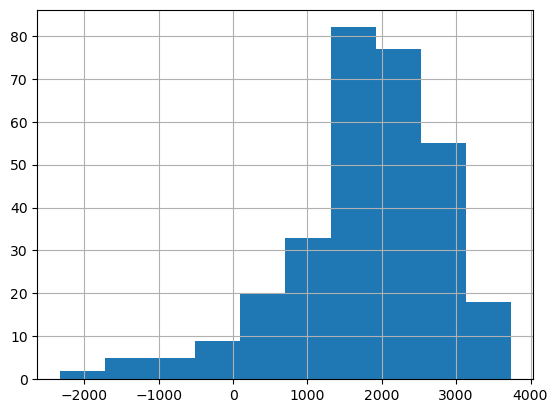

In [193]:
(results['cnt'] - results['cnt_pred']).hist()


In [195]:
r2_score(results['cnt'], results['cnt_pred'])


-0.7345864590267983

In [167]:
root_mean_squared_error(y_test, final_model.predict(X_test))


1161.2692792712455

In [169]:
mean_squared_error(y_test, final_model.predict(X_test))


1348546.338979158

In [171]:
import pandas as pd

print("\n--- Simple Feature Importances (Best Model) ---")

try:
    best_lgbm_model = gs.best_estimator_.named_steps['lgbm']
    importances = best_lgbm_model.feature_importances_
    feature_names = X_train.columns.tolist()

    # 4. Combine names and importances into a Pandas Series and sort
    feature_importance_series = pd.Series(importances, index=feature_names).sort_values(ascending=False)

    # 5. Print the result
    print(feature_importance_series)

except (AttributeError, KeyError) as e:
    print(f"Error accessing feature importances: {e}")
    print("Ensure GridSearchCV (gs) is fitted and contains the pipeline step 'lgbm'.")
except Exception as e:
     print(f"An unexpected error occurred: {e}")



--- Simple Feature Importances (Best Model) ---
atemp               583
hum                 567
windspeed           432
cnt_lag2            333
hum_lag2            301
cnt_lag7            291
hum_roll7_lag2      264
hum_roll3_lag2      260
cnt_diff            250
atemp_roll3_lag2    236
weekday             228
atemp_roll7_lag2    200
weathersit          157
mnth                152
yr                  148
season              107
workingday           83
holiday              33
dtype: int32


**ACTUAL VS PREDICTED**


In [ ]:
import matplotlib.pyplot as plt

# Actual vs. Predicted on the TRAIN set
plt.figure()
plt.plot(range(len(y_train)), y_train, marker='o', label='Train Actual')
plt.plot(range(len(y_train)), y_pred_train, marker='x', label='Train Predicted')
plt.title("TRAIN SET: Actual vs. Predicted")
plt.xlabel("Index (Train Samples)")
plt.ylabel("Target Value")
plt.legend()
plt.show()


**TRAIN SET RESIDUALS**


In [ ]:
# Residuals for the TRAIN set
residuals_train = y_train - y_pred_train

plt.figure()
plt.scatter(range(len(y_train)), residuals_train, marker='o')
plt.axhline(y=0, color='r', linestyle='--')
plt.title("TRAIN SET: Residuals")
plt.xlabel("Index (Train Samples)")
plt.ylabel("Residual (Actual - Predicted)")
plt.show()


**TEST SET: ACTUAL VS. PREDICTED**


In [ ]:
# Make sure you have y_test defined (the actual target values for your test set)
plt.figure()
plt.plot(range(len(y_test)), y_test, marker='o', label='Test Actual')
plt.plot(range(len(y_test)), y_pred_test, marker='x', label='Test Predicted')
plt.title("TEST SET: Actual vs. Predicted")
plt.xlabel("Index (Test Samples)")
plt.ylabel("Target Value")
plt.legend()
plt.show()


**TEST SET RESIDUALS**


In [ ]:
# Residuals for the TEST set
residuals_test = y_test - y_pred_test

plt.figure()
plt.scatter(range(len(y_test)), residuals_test, marker='o')
plt.axhline(y=0, color='r', linestyle='--')
plt.title("TEST SET: Residuals")
plt.xlabel("Index (Test Samples)")
plt.ylabel("Residual (Actual - Predicted)")
plt.show()
